# 01_回归算法-高斯过程

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 高斯过程仍是原来的带噪正弦回归任务，改用 scikit-learn 的 GaussianProcessRegressor，免去 PyTorch/GPyTorch 依赖；区间包含 WhiteKernel 观测噪声。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊一下**高斯过程**。

简单来说，高斯过程是一种用于描述和预测随机变量分布的工具，特别是用于回归和分类问题。它基于**高斯分布**（正态分布），它假设数据点的集合（函数值）可以被视为来自一个高斯分布的随机过程。

### 数学定义

高斯过程可以被视为一个具有无限维度的随机过程，其中每一个有限维的子集（例如，任何有限数量的样本点）服从多维高斯分布。

具体来说，如果我们用 $f(x)$来表示某个输入 $x$对应的函数值，那么我们可以认为这个函数 $f(x)$是一个高斯过程。

用公式表示：


$$
f(x) \sim \mathcal{GP}(m(x), k(x, x'))
$$


其中：

$m(x)$：均值函数（mean function），描述了函数在每个输入点上的平均值。通常情况下，可以取 $m(x) = 0$，即假设函数的平均值为零。

$k(x, x')$：协方差函数（covariance function），又称为核函数（kernel），描述了输入点 $x$和 $x'$之间的相关性。协方差函数决定了高斯过程的“形状”，即数据点之间的相似性和依赖性。

### 直观感受

假设你有一个函数，你不知道它是什么样子的，但你知道它的“行为”应该是什么样的。

比如，它是平滑的、有一定的规律，可能在某些地方高，某些地方低，甚至可能有一些波动。

高斯过程就像是一种工具，帮你“猜测”这个函数的形状。它的基本假设是，函数在不同的输入点上，值之间有某种程度的相关性。例如，靠得很近的输入点可能对应着相似的输出值，而远离的点则可能差异较大。

高斯过程会通过**协方差函数**（也就是核函数）来表示这种相关性。它告诉你，给定两个点，函数值之间的“亲近程度”有多高。比如，两个点之间的距离近，函数值可能差异小；距离远，差异可能大。

### 核函数（协方差函数）

协方差函数（kernel）是高斯过程的核心部分，它决定了函数的光滑性、周期性、趋势等性质。常见的核函数有：

- **平方指数核（RBF核）：** 是最常用的核函数，它假设两个点之间的相似性随着距离的增大而指数衰减，表现出非常平滑的函数行为。
- **线性核：** 用于假设函数在不同位置上的变化是线性的。
- **周期核：** 用于捕捉周期性行为。

### 高斯过程回归

高斯过程回归（Gaussian Process Regression, GPR）是将高斯过程应用于回归任务的方式。假设我们有一组已知的训练数据集 $\{(x_i, y_i)\}$，其中 $y_i$是对应于输入点 $x_i$的函数值（通常是观测值）。

使用高斯过程回归的目标是推测出一个新的输入点 $x_*$的函数值 $y_*$。通过计算训练数据和新输入点之间的相关性，来得到一个预测的分布，而不仅仅是一个确定性的值。预测的结果是一个高斯分布，即一个均值和方差，均值代表预测值，方差代表不确定性。

### 直观的过程

1. **训练阶段：** 你给定一组观测数据，推测出一个高斯过程模型，计算协方差矩阵，找到数据之间的关系。
2. **预测阶段：** 对于一个新的输入点，高斯过程不仅给你一个预测值，还会给出一个不确定度（方差），这样你可以知道这个预测有多可靠。

总的来说，如果你想要一种不依赖具体函数形态但又能灵活捕捉数据特征的方法，高斯过程无疑是一个非常强的选择。

## 理论基础

高斯过程不仅可以为数据建模提供概率性的预测，还能够自然地衡量预测的不确定性。为了深入理解高斯过程，我们从其数学原理和算法流程详细展开。

### 1. 高斯过程数学原理

一个高斯过程是一个随机过程，其中任何有限维的子集都服从多元高斯分布。简而言之，高斯过程可以看作是定义在输入空间上的一个无限维随机变量集合，其每个有限子集的联合分布为多元高斯分布。

我们可以表示高斯过程为：  
$f(x) \sim \mathcal{GP}(m(x), k(x, x'))$  
其中：

$f(x)$是在输入 $x$处的函数值。

$m(x)$是均值函数，通常取为 0，即假设函数的期望为零，$m(x) = 0$。

$k(x, x')$是协方差函数（也称为核函数），用于描述不同输入之间的相似性。

协方差函数决定了函数的平滑性、周期性等特性，核函数的选择对模型的行为有重要影响。常见的核函数有**平方指数核**（RBF核）、**线性核**、**周期性核**等。

**核函数的作用**:

核函数 $k(x, x')$决定了高斯过程的协方差结构，它表示了两个输入点 $x$和 $x'$之间的相关性。核函数的不同选择会影响到模型的输出特性，例如是否具有平滑性、周期性等。常用的核函数有：

- **平方指数核（RBF核）**：用于捕捉平滑变化  
$k(x, x') = \exp\left(-\frac{\|x - x'\|^2}{2 \sigma^2}\right)$  
其中，$\sigma$是尺度参数，控制函数变化的平滑度。
- **线性核**：假设函数是线性变化的  
$k(x, x') = \sigma^2 + \theta (x \cdot x')$
- **周期性核**：用于建模周期性变化  
$k(x, x') = \exp\left(-\frac{2 \sin^2\left(\frac{\pi |x - x'|}{p}\right)}{\ell^2}\right)$  
其中，$p$为周期参数，$\ell$控制变化的平滑度。

**多维高斯分布的推导**:

如果我们有一组训练数据 $\{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}$，并且这些数据是从一个高斯过程模型中采样的，那么这些观测值可以表示为一个多维高斯分布。假设每个 $y_i$对应于 $f(x_i)$，我们可以写出：  
$\mathbf{y} = (y_1, y_2, \dots, y_n) \sim \mathcal{N}(m(X), K(X, X))$  
其中：

$\mathbf{y}$是训练数据的目标值（或标签），即 $\mathbf{y} = (y_1, y_2, \dots, y_n)^\top$。

$m(X)$是输入数据 $X = (x_1, x_2, \dots, x_n)$对应的均值函数，通常为 0（即假设函数均值为零）。

$K(X, X)$是训练数据的协方差矩阵，由核函数 $k(x_i, x_j)$计算得到。

对于新的测试点 $x_*$，我们希望得到 $f(x_*)$的预测值。由于高斯过程是连续且平滑的，它能够为新的输入提供一个联合高斯分布。

**高斯过程的联合分布**:

对于训练集 $X = (x_1, x_2, \dots, x_n)$和一个新的输入 $x_*$，我们希望得到 $f_* = f(x_*)$的预测值。我们可以得到训练数据和测试数据的联合高斯分布：  
$\begin{pmatrix}\mathbf{y} \\\mathbf{f}_*\end{pmatrix}\sim \mathcal{N} \left( \mathbf{0}, \begin{pmatrix}K(X, X) & K(X, x_*) \\K(x_*, X) & K(x_*, x_*)\end{pmatrix} \right)$  
这里：

$K(X, X)$是训练数据之间的协方差矩阵。

$K(X, x_*)$是训练数据和测试数据之间的协方差向量。

$K(x_*, x_*)$是测试数据的协方差。

**条件分布推导**:

根据多元高斯分布的条件分布公式，可以求出测试点 $f_*$的预测分布：  
$\mathbf{f}_* | X, \mathbf{y} \sim \mathcal{N}\left(K(X, x_*)^\top K(X, X)^{-1} \mathbf{y}, K(x_*, x_*) - K(X, x_*)^\top K(X, X)^{-1} K(X, x_*)\right)$  
其中：

- 均值 $K(X, x_*)^\top K(X, X)^{-1} \mathbf{y}$是给定训练数据后对 $f(x_*)$的预测值。
- 方差 $K(x_*, x_*) - K(X, x_*)^\top K(X, X)^{-1} K(X, x_*)$是预测的方差，表示预测的不确定性。

### 2. 高斯过程回归算法流程

**输入与输出**:

- **输入：** 一组训练数据 $\{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}$，以及测试点 $x_*$。
- **输出：** 测试点 $x_*$对应的预测值 $f_*$的均值和方差。

**高斯过程回归的步骤**:

1. **选择核函数：** 根据问题背景选择合适的核函数 $k(x, x')$（如 RBF 核、线性核等）。
2. **计算协方差矩阵：**

   - 计算训练数据之间的协方差矩阵 $K(X, X)$。
   - 计算训练数据与测试点之间的协方差向量 $K(X, x_*)$。
   - 计算测试点之间的协方差 $K(x_*, x_*)$。
3. **求解预测分布：**

   - 计算预测的均值： $\mu_* = K(X, x_*)^\top K(X, X)^{-1} \mathbf{y}$。
   - 计算预测的方差： $\sigma_*^2 = K(x_*, x_*) - K(X, x_*)^\top K(X, X)^{-1} K(X, x_*)$。
4. **输出结果：**

   - 返回预测的均值 $\mu_*$和方差 $\sigma_*^2$。

**模型的训练**:

高斯过程回归的训练过程实际上是学习核函数的超参数（如尺度参数、长度尺度等）。这个过程通常通过最大化**边际似然函数**（marginal likelihood）来进行，即调整核函数参数，使得模型的拟合效果最佳。

边际似然函数是通过对训练数据的协方差矩阵的行列式和逆矩阵计算得到的：  
$p(\mathbf{y} | X) = \mathcal{N}(\mathbf{y} | 0, K(X, X))$  
最大化边际似然函数通常需要使用数值优化方法，如梯度下降、L-BFGS等。

**预测阶段**:

对于新输入点 $x_*$，通过计算协方差矩阵来推导出预测的均值和方差，表示对新数据的预测结果。

## Python案例

本例对带噪正弦曲线做高斯过程回归。先定义 RBF 核与观测噪声核，再通过对数边际似然优化核参数。图中同时显示真实函数、后验均值以及包含观测噪声的近似 95% 预测区间。尝试改变训练点数量与噪声大小，观察区间如何变化。

拟合后的核： 1.73**2 * RBF(length_scale=0.32) + WhiteKernel(noise_level=0.0295)
对数边际似然： 5.100293600717272


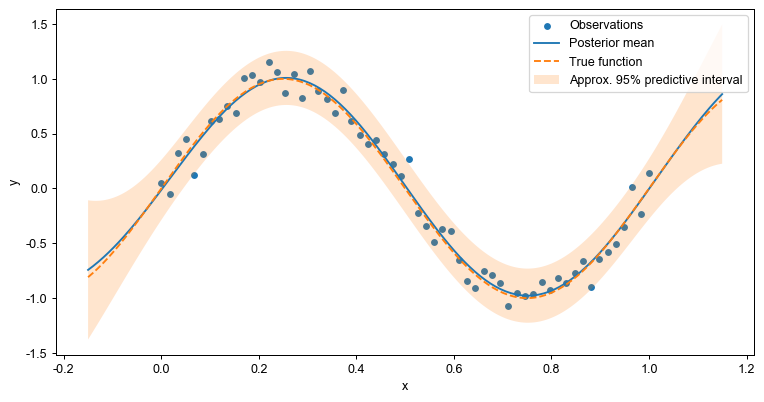

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
rng = np.random.default_rng(42)
X_train = np.linspace(0, 1, 60).reshape(-1, 1)
y_train = np.sin(2 * np.pi * X_train[:, 0]) + rng.normal(0, 0.15, len(X_train))
X_test = np.linspace(-0.15, 1.15, 250).reshape(-1, 1)
kernel = ConstantKernel(1.0, (0.01, 100)) * RBF(0.2, (0.01, 10)) + WhiteKernel(0.02, (1e-5, 1))
model = GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                                n_restarts_optimizer=3, random_state=42)
model.fit(X_train, y_train)
mean, std = model.predict(X_test, return_std=True)
print('拟合后的核：', model.kernel_)
print('对数边际似然：', model.log_marginal_likelihood_value_)
plt.figure(figsize=(10, 5))
plt.scatter(X_train[:, 0], y_train, s=20, label='Observations')
plt.plot(X_test[:, 0], mean, label='Posterior mean')
plt.plot(X_test[:, 0], np.sin(2 * np.pi * X_test[:, 0]), '--', label='True function')
plt.fill_between(X_test[:, 0], mean - 1.96 * std, mean + 1.96 * std,
                 alpha=0.2, label='Approx. 95% predictive interval')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()

## 应用场景

### 高斯过程适用的问题类型

1. **回归问题**：高斯过程可以用于回归任务，其中目标是预测一个连续变量。与传统的回归方法（如线性回归或多项式回归）相比，高斯过程可以提供关于预测的不确定性（即方差），因此非常适合于对预测进行概率建模。
2. **分类问题**：虽然高斯过程本身是一个回归模型，但它也可以扩展到分类问题。通过将高斯过程的输出映射到概率空间（比如使用对数几率回归），它可以进行二分类或多分类。
3. **贝叶斯优化**：在贝叶斯优化中，目标是优化一个未知的、计算开销高且不可导的黑箱函数。高斯过程在这种情境下常用作代理模型，通过不断更新高斯过程模型来指导搜索空间中最优解的探索。
4. **时间序列预测**：高斯过程通过其内建的平滑性假设，能够很好地建模时间序列数据的趋势、季节性等特性。特别是在数据较少或噪声较大的情况下，高斯过程能够提供强大的建模能力。
5. **机器学习中的不确定性建模**：高斯过程非常适合那些需要对模型预测的不确定性进行建模的问题。例如，在自适应实验设计、探索性数据分析等场景中，通过提供方差估计，高斯过程帮助决策者了解预测的不确定性。

### 高斯过程的优缺点

**优点**:

1. **概率预测**：高斯过程不仅给出预测的均值，还能提供预测的不确定性（方差）。这对于许多实际应用非常重要，尤其是在决策过程中需要考虑不确定性时。
2. **非参数性质**：高斯过程不假设数据的具体函数形式，而是通过协方差函数来捕捉数据的结构。这使得高斯过程在处理复杂、未知的函数关系时表现出色。
3. **灵活性**：通过选择不同的核函数，用户可以控制模型的光滑性、周期性、趋势性等。这样，高斯过程可以很好地适应不同的真实世界问题。
4. **平滑性**：高斯过程通常假设数据是平滑的，因此能够较好地避免过拟合，尤其是在数据较少的情况下，能够提供更为合理的预测。

**缺点**：

1. **计算复杂度**：高斯过程的训练需要计算协方差矩阵的逆，这个过程的时间复杂度是 $O(n^3)$，其中 $n$是训练数据的大小。这使得高斯过程在数据量较大时计算非常昂贵，尤其是对于大规模数据集。
2. **内存消耗大**：高斯过程的协方差矩阵大小为 $n \times n$，对于大数据集，需要大量的内存来存储这个矩阵。
3. **核函数选择**：高斯过程的性能高度依赖于选择的核函数。不同的核函数会导致不同的拟合效果，选择合适的核函数需要一定的经验或先验知识。
4. **需要先验知识**：核函数的选择和超参数的优化需要通过实验或其他方法来决定，而这通常需要一定的先验知识。如果没有合适的核函数或参数设置，可能导致模型拟合效果不好。

### 高斯过程的运用前提条件

1. **数据量不宜过大**：高斯过程的计算复杂度是 $O(n^3)$，因此它适用于数据量较小或中等规模的情况（通常在几百到几千个样本之间）。
2. **数据的平滑性和连续性**：高斯过程假设数据是平滑和连续的，因此它适用于那些变化较为平滑且无剧烈波动的数据（例如物理现象、时间序列数据等）。对于具有极端波动的数据，可能需要对模型进行适当的调整。
3. **协方差函数的选择**：合适的核函数对于高斯过程的性能至关重要，必须根据实际问题的特性（如平滑性、周期性等）选择合适的核函数。否则，模型可能会过拟合或欠拟合。
4. **噪声和不确定性**：高斯过程适合那些数据具有一定噪声或不确定性的场景，它能够自然地处理这种不确定性并提供方差估计。

整体来说，高斯过程将函数视为无限维高斯分布的采样，它通过核函数建模输入点之间的相关性，从而对未知函数进行预测并给出不确定性估计。高斯过程回归在数据量不大、对预测可信度要求高的任务中具有强大优势。